# **Week 1 Notebook**
**Lundy Zheng**

For the first week of the Lendo Capital internship, I will mostly be working on some setup work. Notably, I've set up a conda environment, a GitHub repository, and organized a place where my work will be completed. In particular, I've also completed some preliminary data compilation work.

# Task 1
This is completed; check install requirements with: pip install -r requirements.txt

# Task 2

The goal of this task is to: 1. set up the function to grab datasets using yfinance; 2. load in a sample dataset and arrange it into the desired form.

In [11]:
#Download Packages
import yfinance as yf
import pandas as pd
import numpy as np
import pyarrow
import matplotlib.pyplot as plt

In [12]:
#49 Tickers from S&P500 and SPY (50 total)
tickers = [
    "NVDA", "AAPL", "GOOGL", "GOOG", "MSFT", "AMZN", "META", "AVGO", "TSLA", "MU",
    "BRK-B", "LLY", "AMD", "JPM", "WMT", "V", "XOM", "INTC", "JNJ", "MA",
    "ABBV", "ORCL", "DIS", "CSCO", "CVX", "COST", "BAC", "LRCX", "KO", "AMAT",
    "MRK", "CAT", "DELL", "PG", "UNH", "GE", "MS", "PANW", "HD", "NFLX",
    "PM", "GS", "IBM", "ANET", "WFC", "CRWD", "RTX", "VZ", "TXN", "SPY"
]

start_date = "2020-01-01"
end_date = "2025-12-31"

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False
)

data.head()

[*********************100%***********************]  50 of 50 completed


Price       Adj Close                                                         \
Ticker           AAPL       ABBV       AMAT        AMD       AMZN       ANET   
Date                                                                           
2020-01-02  72.271538  68.210724  58.563953  49.099998  94.900497  12.795000   
2020-01-03  71.568947  67.563278  57.631821  48.599998  93.748497  12.553125   
2020-01-06  72.139191  68.096466  56.388985  48.389999  95.143997  12.678750   
2020-01-07  71.799919  67.708000  58.017864  48.250000  95.343002  12.803125   
2020-01-08  72.954903  68.187889  57.980209  47.830002  94.598503  12.936250   

Price                                                     ...   Volume  \
Ticker           AVGO        BAC       BRK-B         CAT  ...      RTX   
Date                                                      ...            
2020-01-02  27.583525  30.274990  228.389999  132.067902  ...  4451584   
2020-01-03  26.881943  29.646391  226.179993  130.234268  ...  4969756   
2020-01-06  26.841728  29.603910  226.990005  130.146454  ...  4139504   
2020-01-07  26.749329  29.408535  225.919998  128.426849  ...  4348775   
2020-01-08  26.415646  29.705853  225.990005  129.567398  ...  3772445   

Price                                                                  \
Ticker           SPY       TSLA      TXN      UNH         V        VZ   
Date                                                                    
2020-01-02  59151200  142981500  4614000  2543400   8733000  11447900   
2020-01-03  77709700  266677500  4057200  2711400   4899700  13263200   
2020-01-06  55653900  151995000  4345400  3079100  10109500  15094500   
2020-01-07  40496400  268231500  7184100  2492900   4392300  14293100   
2020-01-08  68296000  467164500  3546900  3379200   5712000  15926500   

Price                                     
Ticker           WFC       WMT       XOM  
Date                                      
2020-01-02  16803100  20294700  12456400  
2020-01-03  15608800  16197600  17386900  
2020-01-06  13200300  19336500  20081900  
2020-01-07  13278600  20540700  17387700  
2020-01-08  16585600  17627400  15137700  

[5 rows x 300 columns]

In [13]:
#Clean data to what we want it to look like
df = data.stack(level="Ticker", future_stack=True).reset_index()

df = df.rename(columns={
    "Date": "date",
    "Ticker": "ticker",
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close": "close",
    "Adj Close": "adjusted_close",
    "Volume": "volume"
})

df = df[
    [
        "date",
        "ticker",
        "open",
        "high",
        "low",
        "close",
        "adjusted_close",
        "volume",
    ]
]

df.columns.name = None

df.head(5)

,date,ticker,open,high,low,close,adjusted_close,volume
0,2020-01-02,AAPL,74.059998,75.150002,73.797501,75.087502,72.271538,135480400
1,2020-01-02,ABBV,89.080002,89.570000,88.510002,89.550003,68.210724,5639200
2,2020-01-02,AMAT,62.000000,62.650002,61.700001,62.200001,58.563953,6647900
3,2020-01-02,AMD,46.860001,49.250000,46.630001,49.099998,49.099998,80331100
4,2020-01-02,AMZN,93.750000,94.900497,93.207497,94.900497,94.900497,80580000


In [14]:
#Now that the dataset is arranged properly, we will download it and be able to pull it with the load_ohlcv() function.
df.to_csv(
    "../data/processed/ohlcv.csv",
    index=False
)

#GPT recommended this file format rather than the usual csv. I'll go with this for now.
df.to_parquet(
    "../data/processed/ohlcv.parquet",
    index=False
)

def load_ohlcv(path):
    """
    This function reads a .parquet file into a the notebook as a dataset (df).
    Input: path (of file)
    Output: dataframe
    """
    
    df = pd.read_parquet(path)

    df["date"] = pd.to_datetime(df["date"])

    df = df.sort_values(
        ["ticker", "date"]
    ).reset_index(drop=True)

    return df

# Task 3

Next, we conduct a data quality check of the dataset processed in Task 2. Checking notably for:
1. Missing data - if = NaN
2. Duplicate rows/dates - if more than two of the same date appears, for the same ticker
3. Invalid dates - cannot have things like 4/31, for example.
4. Impossible values - price =< 0 or volume <0 is strange
5. Outliers - something extreme? (check values)

In [15]:
#Interlude to task 4: let's compute simple returns here so we can check extreme returns alongside the other checks.
df["daily_simple_return"] = (
    df.groupby("ticker")["adjusted_close"]
      .pct_change(fill_method = None)
)

In [16]:
#Define a bunch of subfunctions we can place in validate_ohlcv

def check_missing_data(df):
    """
    Check if any data is missing.

    Input: dataframe
    Output: dataframe of rows with missing values
    """

    missing = df.isna().sum()

    print("\nMissing values by column:")
    print(missing)

    problem_rows = df[df.isna().any(axis=1)]

    print("\nRows containing missing values: " + str(len(problem_rows)))
    print(problem_rows)

    return problem_rows
    
def check_duplicates(df):
    """
    Check if any duplicate rows exist.
    Note: This counts the number of rows that have a duplicate at all! so 2 rows of the same date --> 2 duplicate rows; 3 rows of the same date --> 3 duplicate rows

    Input: dataframe
    Output: dataframe of duplicate rows
    """

    duplicates = df[
        df.duplicated(
            subset=["ticker", "date"],
            keep=False
        )
    ]

    print("\nNumber of duplicate rows:")
    print(len(duplicates))

    print("\nDuplicate observations:")
    print(duplicates)

    return duplicates

def check_invalid_values(df):
    """
    Here we want to check if prices are invalid - notably, we will make sure that all prices >0, and volume =>0.
    We also must check that high is indeed high, and low is indeed low.

    Input: dataframe
    Output: dataframe of rows with invalid prices
    """

    price_cols = [
        "open",
        "high",
        "low",
        "close",
        "adjusted_close"
    ]
    
    invalid = df[
        (df[price_cols] <= 0).any(axis=1)
        |
        (df["volume"] < 0)
        |
        (df["high"] < df["open"])
        |
        (df["high"] < df["close"])
        |
        (df["high"] < df["low"])
        |
        (df["low"] > df["open"])
        |
        (df["low"] > df["close"])
    ]

    print("\nRows with invalid prices:")
    print(invalid)

    return invalid

def check_valid_date(df, benchmark = "SPY"):
    """
    This function checks that all the dates listed for each stock are actual days when trades are possible.
    I will use SPY as the benchmark (suggested by most online sources; plus, its S&P500) to see if other stocks dates match. But this is just the default and can be changed.

    Input: dataframe, str:ticker
    Output: dataframe of rows with erroneous dates
    """

    benchmark_dates = set(
        df[df["ticker"] == benchmark]["date"]
    )

    tickers = df["ticker"].unique()

    problems = {}

    for ticker in tickers:

        ticker_dates = set(
            df[df["ticker"] == ticker]["date"]
        )

        missing_dates = benchmark_dates - ticker_dates
        extra_dates = ticker_dates - benchmark_dates

        if missing_dates or extra_dates:
            problems[ticker] = {
                "missing_dates": missing_dates,
                "extra_dates": extra_dates
            }

    print("\nCalendar discrepancies:")
    if problems == {}:
        print("No discrepancies!")
    else:
        print(problems)

    return problems

def check_extreme_returns(df, threshold = 0.25):
    """
    This function checks for whether or not the simply daily return for any ticker at any moment is suspiciously high or low.

    Input: dataframe
    Output: dataframe of list of days with suspicious returns, for investigation.
    """
    extreme_returns = df[
        df["daily_simple_return"].abs() > threshold
    ]

    print("\nExtreme daily returns:")
    print(
        extreme_returns[
            ["date", "ticker", "adjusted_close", "daily_simple_return"]
        ]
    )

    return extreme_returns

In [17]:
def validate_ohlcv(df):
    """
    This function provides a series of checks for whether or not the data is clean & devoid of errors.

    Input: dataframe
    Output: relevant info on dataset, warnings for particular instances of values
    """

    #1. Overview: Check the big-scale information about the dataset, including duplicates
    # shape
    print("Shape")
    print(df.shape)
    
    # Overview: Column types
    print("\nColumn Types")
    print(df.dtypes)

    # basic numerical summary
    print("\nSummary")
    print(df.describe())

    # missing values in each column
    missing_rows = check_missing_data(df)
    
    # duplicate ticker-date observations
    duplicates = check_duplicates(df)

    # checking if values are valid
    invalid_values = check_invalid_values(df)

    # checking if dates are valid & complete
    check_valid_date(df)

    # check if any daily simple return is suspiciously high
    check_extreme_returns(df)
    
validate_ohlcv(df)

Shape
(75350, 9)

Column Types
date                   datetime64[ns]
ticker                         object
open                          float64
high                          float64
low                           float64
close                         float64
adjusted_close                float64
volume                          int64
daily_simple_return           float64
dtype: object

Summary
                                date          open          high  \
count                          75350  75350.000000  75350.000000   
mean   2022-12-29 22:34:00.079628288    172.129678    174.060140   
min              2020-01-02 00:00:00      5.002500      5.248500   
25%              2021-06-30 00:00:00     63.240002     63.970001   
50%              2022-12-28 00:00:00    123.610001    125.260002   
75%              2024-07-01 00:00:00    212.687500    215.410004   
max              2025-12-30 00:00:00   1102.000000   1111.989990   
std                              NaN    155.981538    157.46

# Task 4

Here we create a basic function that computes returns. Simple vs log returns are distinguished. Daily, weekly, monthly, and annual returns.
Simple returns over multiple days are compounded. computereturns() function, also in data_utils.py
For a check, we already computed daily simple return above. The rest below are:

1. Weekly simple return (compounded)
2. Monthly simple return (compounded)
3. Daily log return
4. Weekly log return
5. Monthly log return

Product: a compute_returns() function. I envision this function to 1. add daily return (2 types) columns to the existing dataframe, 2. create a new dataframe(s) consisting of date, ticker, and each of daily, weekly, monthly, and annual returns, 3. return distribution plots.

In [18]:
def compute_period_returns(df, frequency = "W-FRI"):
    """
    This is a subfunction for compute_returns that computes a certain frequency of returns based on input.

    Input: dataframe, str:frequency ("W-FRI", "ME", "YE")
    Output: dataframe cropped per period, with returns computed
    """
   
    period_prices = (
    df.set_index("date")
      .groupby("ticker")["adjusted_close"]
      .resample(frequency)
      .last()
      .dropna()
      .reset_index()
    )

    # Instead of compounding by day, AI suggested I compute simple returns through jumping from weekly endpoint to weekly endpoint. I also coded a simple test for if I used the compounding method and they do produce the same results (as we would intuitively expect)
    
    period_prices["simple_return"] = (
    period_prices.groupby("ticker")["adjusted_close"]
                 .pct_change(fill_method=None)
    )

    period_prices["log_return"] = (
    np.log(period_prices["adjusted_close"])
    - np.log(
        period_prices.groupby("ticker")["adjusted_close"].shift(1)
    )
    )

    return period_prices

def compute_returns(df):
    """
    This function computes the daily simple & log returns of each stock, putting them as new columns in a dataframe copy.
    Simple returns are the most intuitive as they calculate percent change in closing price from the previous day. These are generally used in discussion for clarity and ease of understanding.
    Log returns take the log-difference of the closing prices, which is less convenient to think about but is very useful in summing returns, as this metric has an sums well (whereas simple returns require a compound formula).

    Input: dataframe
    Output: dataframe with extra columns on daily returns, dataframe with all types of returns
    """

    df = df.copy()

    # Make sure observations are ordered correctly
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

    # Daily simple return --> already done in this notebook but included here for future ones.
    df["daily_simple_return"] = (
        df.groupby("ticker")["adjusted_close"]
          .pct_change(fill_method=None)
    )

    # Daily log return
    df["daily_log_return"] = (
        np.log(df["adjusted_close"])
        - np.log(
            df.groupby("ticker")["adjusted_close"].shift(1)
        )
    )

    daily = df[
        ["date", "ticker", "daily_simple_return", "daily_log_return"]
    ].copy()
    
    daily = daily.rename(
        columns={
            "daily_simple_return": "simple_return",
            "daily_log_return": "log_return"
        }
    )

    daily["frequency"] = "daily"
    
    # Weekly
    weekly = compute_period_returns(df, "W-FRI")
    weekly["frequency"] = "weekly"

    # Monthly
    monthly = compute_period_returns(df, "ME")
    monthly["frequency"] = "monthly"

    # Annual (not required)
    annual = compute_period_returns(df, "YE")
    annual["frequency"] = "annual"

    # Check columns are consistent
    columns = [
    "date",
    "ticker",
    "simple_return",
    "log_return",
    "frequency"
    ]
    
    daily = daily[columns]
    weekly = weekly[columns]
    monthly = monthly[columns]
    annual = annual[columns]

    # Combine all these calculated values into one dataframe,
    returns_df = pd.concat(
        [daily, weekly, monthly, annual],
        ignore_index=True
    )

    return df, returns_df

df, returns_df = compute_returns(df)
returns_df.head()

,date,ticker,simple_return,log_return,frequency
0,2020-01-02,AAPL,NaN,NaN,daily
1,2020-01-03,AAPL,-0.009722,-0.009769,daily
2,2020-01-06,AAPL,0.007968,0.007936,daily
3,2020-01-07,AAPL,-0.004703,-0.004714,daily
4,2020-01-08,AAPL,0.016086,0.015958,daily


In [19]:
# I find the returns_df dataframe rather annoying to read so I separated them here again for clarity:
daily_returns = returns_df[
    returns_df["frequency"] == "daily"
].drop(columns="frequency").reset_index(drop=True).copy()

weekly_returns = returns_df[
    returns_df["frequency"] == "weekly"
].drop(columns="frequency").reset_index(drop=True).copy()

monthly_returns = returns_df[
    returns_df["frequency"] == "monthly"
].drop(columns="frequency").reset_index(drop=True).copy()

annual_returns = returns_df[
    returns_df["frequency"] == "annual"
].drop(columns="frequency").reset_index(drop=True).copy()

print("Daily")
display(daily_returns.head())

print("Weekly")
display(weekly_returns.head())

print("Monthly")
display(monthly_returns.head())

print("Annual")
display(annual_returns.head(10))

Daily


,date,ticker,simple_return,log_return
0,2020-01-02,AAPL,NaN,NaN
1,2020-01-03,AAPL,-0.009722,-0.009769
2,2020-01-06,AAPL,0.007968,0.007936
3,2020-01-07,AAPL,-0.004703,-0.004714
4,2020-01-08,AAPL,0.016086,0.015958


Weekly


,date,ticker,simple_return,log_return
0,2020-01-03,AAPL,NaN,NaN
1,2020-01-10,AAPL,0.043371,0.042457
2,2020-01-17,AAPL,0.027068,0.026708
3,2020-01-24,AAPL,-0.001318,-0.001319
4,2020-01-31,AAPL,-0.027646,-0.028035


Monthly


,date,ticker,simple_return,log_return
0,2020-01-31,AAPL,NaN,NaN
1,2020-02-29,AAPL,-0.114702,-0.121831
2,2020-03-31,AAPL,-0.069761,-0.072314
3,2020-04-30,AAPL,0.155374,0.144424
4,2020-05-31,AAPL,0.085094,0.081667


Annual


,date,ticker,simple_return,log_return
0,2020-12-31,AAPL,NaN,NaN
1,2021-12-31,AAPL,0.346482,0.297495
2,2022-12-31,AAPL,-0.264042,-0.306582
3,2023-12-31,AAPL,0.490081,0.398830
4,2024-12-31,AAPL,0.307052,0.267775
5,2025-12-31,AAPL,0.095420,0.091138
6,2020-12-31,ABBV,NaN,NaN
7,2021-12-31,ABBV,0.324260,0.280854
8,2022-12-31,ABBV,0.240077,0.215173
9,2023-12-31,ABBV,-0.002348,-0.002351


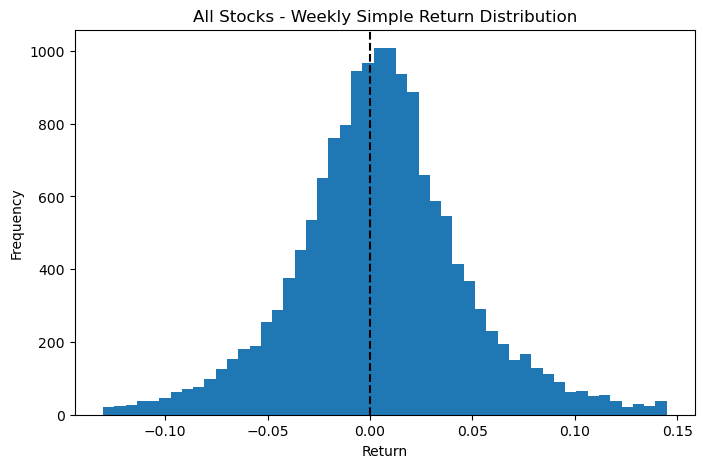

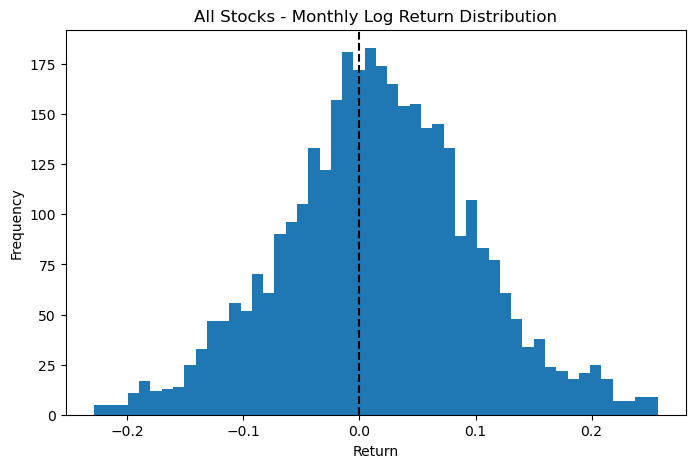

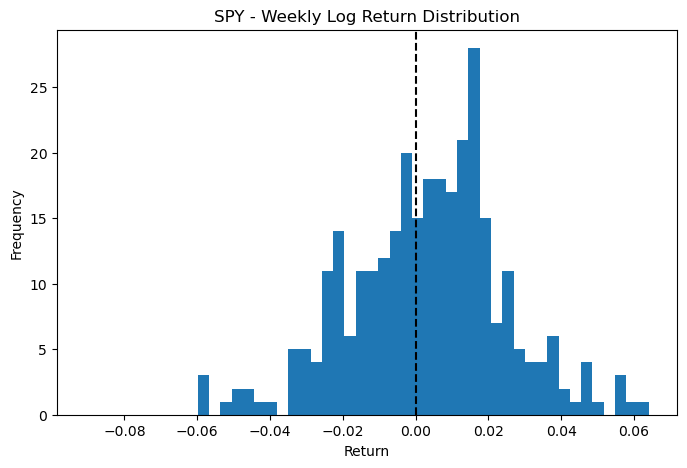

In [20]:
# The final goal of this task is to create return distribution plots. Do the most basic histogram (and I can try to improve from here)

def plot_return_distribution(
    returns_df,
    frequency,
    return_type="simple_return",
    bins=50,
    tickers=None
):
    """
    Plot the distribution of returns for a given frequency and return type.

    Input: returns_df (dataframe), frequency ("daily", "weekly", "monthly", "annual"),
           return_type ("simple_return" or "log_return"), bins,
           tickers (optional, list of tickers)
    Output: plot
    """

    data = returns_df[
        returns_df["frequency"] == frequency
    ].copy()

    # Filter by ticker(s) only when specified in argument (for selecting a few companies or a benchmark)
    if tickers is not None:
        if isinstance(tickers, str):
            tickers = [tickers]

        data = data[
            data["ticker"].isin(tickers)
        ]
    if tickers is None:
        ticker_title = "All Stocks"
    else:
        ticker_title = ", ".join(tickers)

    data = data[return_type].dropna()
    
    # So the range on the plot isn't very big
    lower = data.quantile(0.01)
    upper = data.quantile(0.99)

    plt.figure(figsize=(8, 5))

    plt.axvline(0, linestyle="--", color="k")

    plt.hist(
        data,
        bins=bins,
        range=(lower, upper)
    )

    plt.title(
        f"{ticker_title} - {frequency.capitalize()} "
        f"{return_type.replace('_', ' ').title()} Distribution"
    )

    plt.xlabel("Return")
    plt.ylabel("Frequency")

    plt.show()

plot_return_distribution(returns_df, "weekly", "simple_return")
plot_return_distribution(returns_df, "monthly", "log_return")
plot_return_distribution(returns_df, "weekly", "log_return", tickers=["SPY"])